<a href="https://colab.research.google.com/github/DynamicFostel/DynamicFostel/blob/main/UAV_Imagery_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# Install rasterio (easier than raw GDAL bindings, and works reliably in Colab)
!pip install rasterio -q

Uploading Band **files** **bold text**

In [2]:
from google.colab import files
uploaded = files.upload()

Saving UAV_Worth_2_transparent_mosaic_green.tif to UAV_Worth_2_transparent_mosaic_green.tif
Saving UAV_Worth_2_transparent_mosaic_nir.tif to UAV_Worth_2_transparent_mosaic_nir.tif
Saving UAV_Worth_2_transparent_mosaic_red edge.tif to UAV_Worth_2_transparent_mosaic_red edge.tif
Saving UAV_Worth_2_transparent_mosaic_red.tif to UAV_Worth_2_transparent_mosaic_red.tif


Check Alignment

In [9]:
import rasterio

band_files = {
    "green": "/content/UAV_Worth_2_transparent_mosaic_green.tif",
    "red": "/content/UAV_Worth_2_transparent_mosaic_red.tif",
    "nir": "/content/UAV_Worth_2_transparent_mosaic_nir.tif",
    "red_edge": "/content/UAV_Worth_2_transparent_mosaic_red edge.tif", # Added red_edge band
}

info = {}
for name, path in band_files.items():
    with rasterio.open(path) as src:
        info[name] = {
            "width": src.width,
            "height": src.height,
            "crs": src.crs,
            "transform": src.transform,
            "bounds": src.bounds,
            "dtype": src.dtypes[0],
            "nodata": src.nodata,
        }

for name, meta in info.items():
    print(f"--- {name} ---")
    for k, v in meta.items():
        print(f"  {k}: {v}")
    print()

--- green ---
  width: 8470
  height: 10319
  crs: EPSG:32617
  transform: | 0.02, 0.00, 254521.97|
| 0.00,-0.02, 3474547.56|
| 0.00, 0.00, 1.00|
  bounds: BoundingBox(left=254521.97216000003, bottom=3474336.538, right=254695.18366000004, top=3474547.56155)
  dtype: uint16
  nodata: None

--- red ---
  width: 8470
  height: 10319
  crs: EPSG:32617
  transform: | 0.02, 0.00, 254521.97|
| 0.00,-0.02, 3474547.56|
| 0.00, 0.00, 1.00|
  bounds: BoundingBox(left=254521.97216000003, bottom=3474336.538, right=254695.18366000004, top=3474547.56155)
  dtype: uint16
  nodata: None

--- nir ---
  width: 8470
  height: 10319
  crs: EPSG:32617
  transform: | 0.02, 0.00, 254521.97|
| 0.00,-0.02, 3474547.56|
| 0.00, 0.00, 1.00|
  bounds: BoundingBox(left=254521.97216000003, bottom=3474336.538, right=254695.18366000004, top=3474547.56155)
  dtype: uint16
  nodata: None

--- red_edge ---
  width: 8470
  height: 10319
  crs: EPSG:32617
  transform: | 0.02, 0.00, 254521.97|
| 0.00,-0.02, 3474547.56|
| 0.0

In [16]:
ref = list(info.values())[0]
for name, meta in info.items():
    mismatches = []
    if meta["width"] != ref["width"] or meta["height"] != ref["height"]:
        mismatches.append("dimensions")
    if meta["crs"] != ref["crs"]:
        mismatches.append("CRS")
    if meta["transform"] != ref["transform"]:
        mismatches.append("transform/pixel size")
    if mismatches:
        print(f"{name}: MISMATCH in {mismatches}")
    else:
        print(f"{name}: matches reference")

green: matches reference
red: matches reference
nir: matches reference
red_edge: matches reference


In [10]:
ref = list(info.values())[0]
for name, meta in info.items():
    mismatches = []
    if meta["width"] != ref["width"] or meta["height"] != ref["height"]:
        mismatches.append("dimensions")
    if meta["crs"] != ref["crs"]:
        mismatches.append("CRS")
    if meta["transform"] != ref["transform"]:
        mismatches.append("transform/pixel size")
    if mismatches:
        print(f"{name}: MISMATCH in {mismatches}")
    else:
        print(f"{name}: matches reference")

green: matches reference
red: matches reference
nir: matches reference
red_edge: matches reference


In [17]:
import rasterio
from rasterio.warp import reproject, Resampling
import numpy as np

# Use the first band as the reference grid
# It is already correctly set to the green band
ref_path = "/content/UAV_Worth_2_transparent_mosaic_green.tif"
with rasterio.open(ref_path) as ref_src:
    ref_transform = ref_src.transform
    ref_crs = ref_src.crs
    ref_width = ref_src.width
    ref_height = ref_src.height

def resample_to_reference(src_path, out_path):
    with rasterio.open(src_path) as src:
        dst_array = np.empty((ref_height, ref_width), dtype=src.dtypes[0])
        reproject(
            source=rasterio.band(src, 1),
            destination=dst_array,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=ref_transform,
            dst_crs=ref_crs,
            resampling=Resampling.bilinear,
        )
        out_meta = src.meta.copy()
        out_meta.update({
            "height": ref_height,
            "width": ref_width,
            "transform": ref_transform,
            "crs": ref_crs,
        })
        with rasterio.open(out_path, "w", **out_meta) as dst:
            dst.write(dst_array, 1)

# Resample any mismatched bands using the correct file paths from uploaded data
# The band_files dictionary from cell AaPDxM6QXfZ1 contains the correct paths.
resample_to_reference(band_files["green"], "/content/green_resampled.tif")
resample_to_reference(band_files["red"], "/content/red_resampled.tif")
resample_to_reference(band_files["nir"], "/content/nir_resampled.tif")
resample_to_reference(band_files["red_edge"], "/content/red_edge_resampled.tif") # Resample red_edge band


In [20]:
import rasterio

# Updated band_order to reflect available bands, including red_edge
band_order = ["green", "red", "nir", "red_edge"]  # set this to YOUR desired output order

# Updated band_files_final to use resampled versions where created
band_files_final = {
    "green": "/content/green_resampled.tif",   # use resampled version if applicable
    "red": "/content/red_resampled.tif",
    "nir": "/content/nir_resampled.tif",
    "red_edge": "/content/red_edge_resampled.tif", # use resampled version for red_edge
}

# Use the first band as template for metadata
with rasterio.open(band_files_final[band_order[0]]) as src0:
    meta = src0.meta.copy()

meta.update(count=len(band_order))

output_path = "/content/stacked_4band.tif"

with rasterio.open(output_path, "w", **meta) as dst:
    for i, band_name in enumerate(band_order, start=1):
        with rasterio.open(band_files_final[band_name]) as src:
            dst.write(src.read(1), i)
        dst.set_band_description(i, band_name)  # label the band

print("Stacked file written to:", output_path)

Stacked file written to: /content/stacked_4band.tif


In [19]:
import rasterio

# Updated band_order to reflect available bands, including red_edge
band_order = ["green", "red", "nir", "red_edge"]  # set this to YOUR desired output order

# Updated band_files_final to use resampled versions where created
band_files_final = {
    "green": "/content/green_resampled.tif",   # use resampled version if applicable
    "red": "/content/red_resampled.tif",
    "nir": "/content/nir_resampled.tif",
    "red_edge": "/content/red_edge_resampled.tif", # use resampled version for red_edge
}

# Use the first band as template for metadata
with rasterio.open(band_files_final[band_order[0]]) as src0:
    meta = src0.meta.copy()

meta.update(count=len(band_order))

output_path = "/content/stacked_4band.tif"

with rasterio.open(output_path, "w", **meta) as dst:
    for i, band_name in enumerate(band_order, start=1):
        with rasterio.open(band_files_final[band_name]) as src:
            dst.write(src.read(1), i)
        dst.set_band_description(i, band_name)  # label the band

print("Stacked file written to:", output_path)

Stacked file written to: /content/stacked_4band.tif


In [21]:
with rasterio.open(output_path) as src:
    print("Band count:", src.count)
    print("Descriptions:", src.descriptions)
    print("CRS:", src.crs)
    print("Size:", src.width, src.height)

Band count: 4
Descriptions: ('green', 'red', 'nir', 'red_edge')
CRS: EPSG:32617
Size: 8470 10319


In [22]:
from google.colab import files
files.download("/content/stacked_4band.tif")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Quality Check of Stacked Image

Let's perform some quality checks on the newly created `stacked_4band.tif` file. This includes visual inspection, checking basic band statistics, and visualizing pixel value distributions with histograms.

Band descriptions: ('green', 'red', 'nir', 'red_edge')


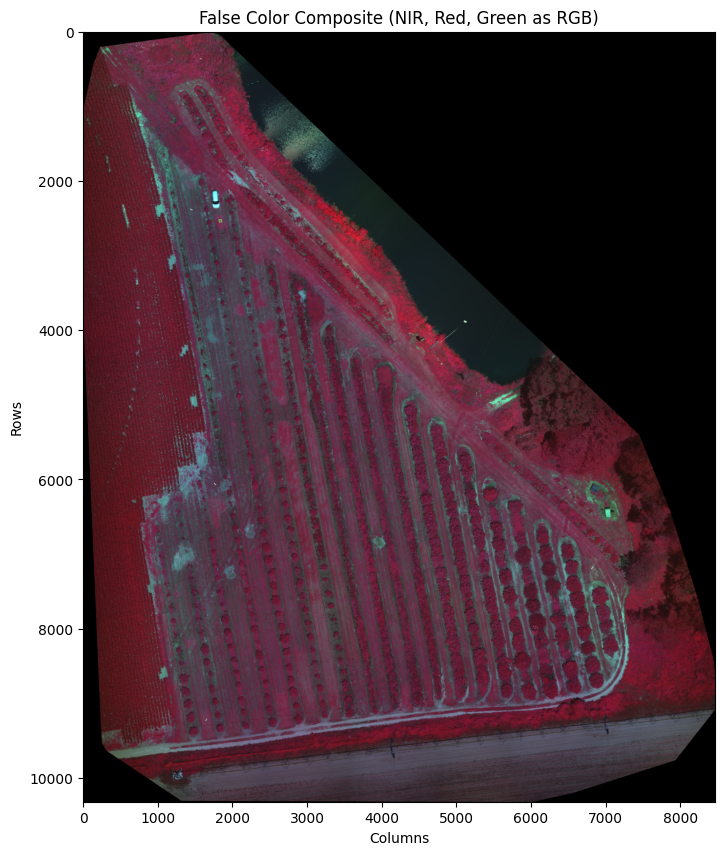

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import rasterio

# Open the stacked image
output_path = "/content/stacked_4band.tif"
with rasterio.open(output_path) as src:
    stacked_data = src.read()
    band_descriptions = src.descriptions

# Assuming band order: Green, Red, NIR, Red_Edge
# Create an RGB composite for visual inspection (using Green, Red as R/G, can't use Blue)
# For a true RGB, you'd need a blue band. Here we'll use a false color composite.
# Let's try a False Color Composite (FCC) using NIR, Red, Green as R,G,B for vegetation analysis

# Normalize the bands to 0-255 for display
def normalize(band):
    return ((band - np.min(band)) / (np.max(band) - np.min(band)) * 255).astype(np.uint8)

# Assuming band order is [green, red, nir, red_edge]
# Indices: Green=0, Red=1, NIR=2, Red_Edge=3

# Let's create a standard False Color Composite (FCC): NIR-Red-Green (as RGB)
# This means NIR goes to Red channel, Red goes to Green channel, Green goes to Blue channel
# If we want to use the actual band descriptions, we need to map them.
# Let's verify band order before proceeding
print(f"Band descriptions: {band_descriptions}")

# Find indices for the bands needed for FCC (NIR, Red, Green)
try:
    nir_idx = band_descriptions.index('nir')
    red_idx = band_descriptions.index('red')
    green_idx = band_descriptions.index('green')
except ValueError as e:
    print(f"Error: Missing expected band for FCC: {e}. Please ensure 'nir', 'red', and 'green' bands are present.")
    # Fallback or exit if critical bands are missing
    if len(band_descriptions) >= 3: # Use first 3 bands if named ones are missing
        nir_idx, red_idx, green_idx = 2, 1, 0 # Assuming 'nir' 'red' 'green' order in stacked_data
    else:
        raise SystemExit("Not enough bands to create a composite image.")

fcc_image = np.zeros((stacked_data.shape[1], stacked_data.shape[2], 3), dtype=np.uint8)
fcc_image[:,:,0] = normalize(stacked_data[nir_idx, :, :]) # NIR to Red channel
fcc_image[:,:,1] = normalize(stacked_data[red_idx, :, :]) # Red to Green channel
fcc_image[:,:,2] = normalize(stacked_data[green_idx, :, :]) # Green to Blue channel

plt.figure(figsize=(10, 10))
plt.imshow(fcc_image)
plt.title('False Color Composite (NIR, Red, Green as RGB)')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()


In [24]:
# Display basic statistics for each band
print("\n--- Band Statistics ---")
for i, band_name in enumerate(band_descriptions):
    band_data = stacked_data[i, :, :]
    print(f"Band: {band_name}")
    print(f"  Min: {np.min(band_data):.2f}")
    print(f"  Max: {np.max(band_data):.2f}")
    print(f"  Mean: {np.mean(band_data):.2f}")
    print(f"  Std Dev: {np.std(band_data):.2f}")
    print("\n")


--- Band Statistics ---
Band: green
  Min: 0.00
  Max: 65059.00
  Mean: 11411.16
  Std Dev: 8961.67


Band: red
  Min: 0.00
  Max: 65520.00
  Mean: 9010.23
  Std Dev: 7773.97


Band: nir
  Min: 0.00
  Max: 52978.00
  Mean: 12820.43
  Std Dev: 9214.52


Band: red_edge
  Min: 0.00
  Max: 65195.00
  Mean: 14543.97
  Std Dev: 10861.36




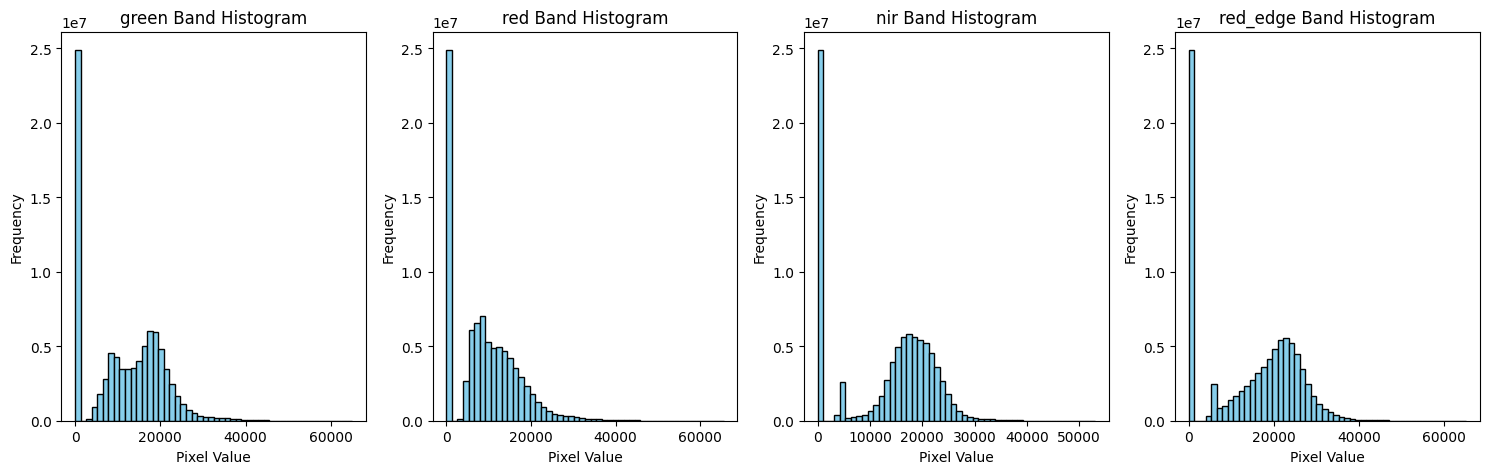

In [25]:
# Plot histograms for each band
plt.figure(figsize=(15, 5))
for i, band_name in enumerate(band_descriptions):
    plt.subplot(1, len(band_descriptions), i + 1)
    plt.hist(stacked_data[i, :, :].flatten(), bins=50, color='skyblue', edgecolor='black')
    plt.title(f'{band_name} Band Histogram')
    plt.xlabel('Pixel Value')
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


## Delineate Individual Citrus Trees

Now, let's proceed with delineating individual citrus trees. This typically involves several steps:
1.  **Calculate Vegetation Index (e.g., NDVI):** To highlight vegetated areas.
2.  **Thresholding:** Create a binary mask to separate vegetation from non-vegetation.
3.  **Morphological Operations:** Clean up the mask.
4.  **Segmentation:** Apply a technique to identify individual tree crowns.

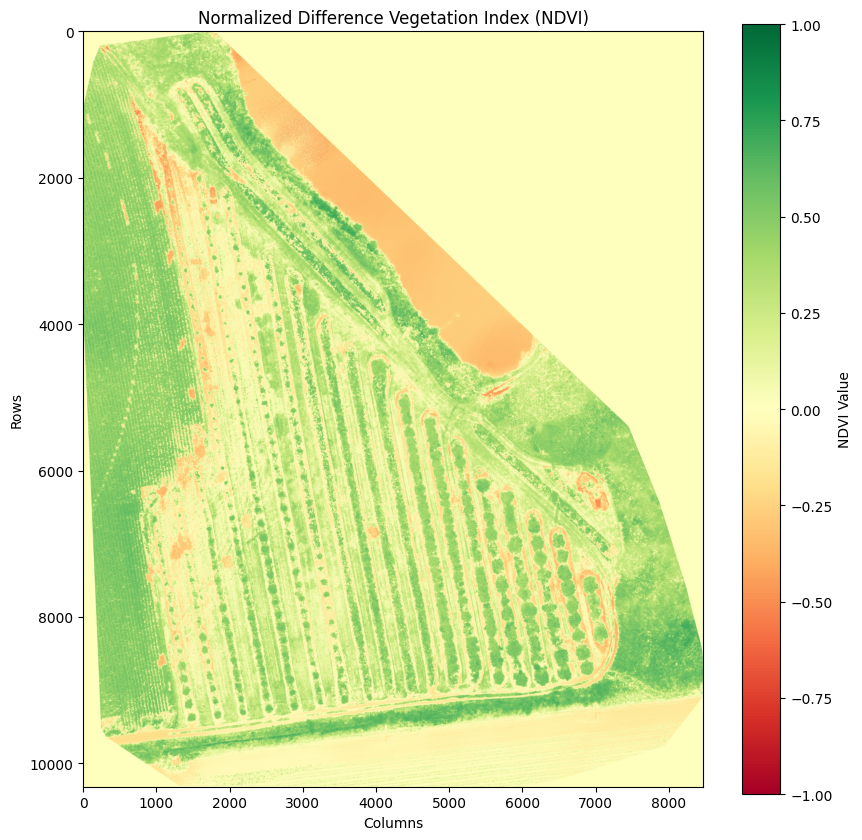

In [26]:
# Calculate NDVI (Normalized Difference Vegetation Index)
# NDVI = (NIR - Red) / (NIR + Red)

# Find indices for NIR and Red bands
try:
    nir_idx = band_descriptions.index('nir')
    red_idx = band_descriptions.index('red')
except ValueError as e:
    raise ValueError(f"Error: Missing 'nir' or 'red' band for NDVI calculation: {e}")

nir_band = stacked_data[nir_idx, :, :].astype(float)
red_band = stacked_data[red_idx, :, :].astype(float)

# Avoid division by zero
sum_bands = nir_band + red_band
sum_bands[sum_bands == 0] = 1e-6 # Replace zero sums with a small number

ndvi = (nir_band - red_band) / sum_bands

# Display the NDVI image
plt.figure(figsize=(10, 10))
plt.imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1) # Red-Yellow-Green colormap
plt.title('Normalized Difference Vegetation Index (NDVI)')
plt.colorbar(label='NDVI Value')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

### 2. Thresholding for Vegetation Mask

We'll apply a threshold to the NDVI image to create a binary mask, separating vegetation (trees) from non-vegetation. You might need to adjust the `ndvi_threshold` value based on the visual inspection of the NDVI image and your specific dataset to get a good vegetation mask.

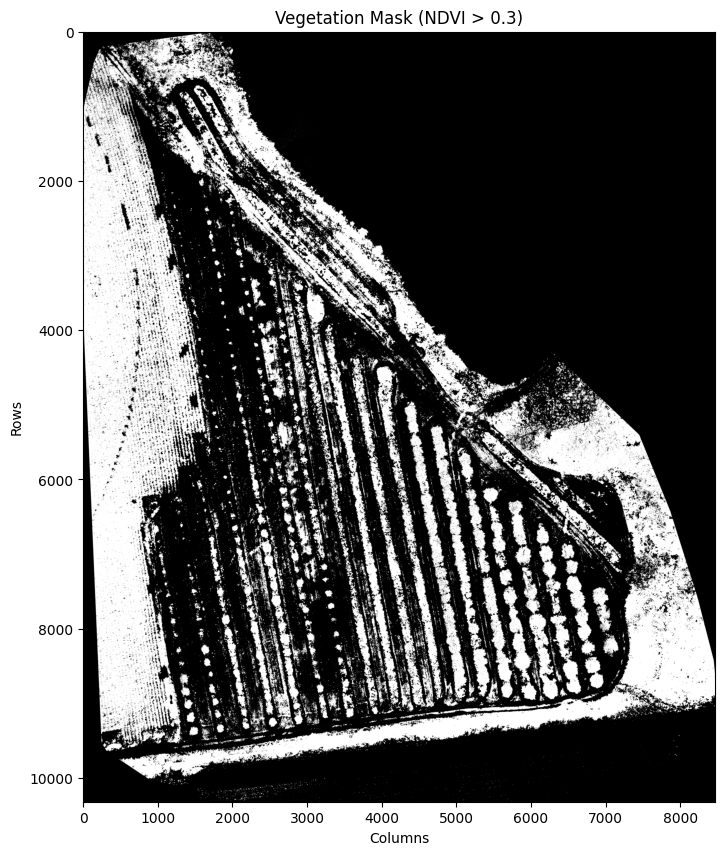

In [27]:
# Apply a threshold to the NDVI to create a binary vegetation mask
# Adjust this threshold value as needed based on your NDVI image
ndvi_threshold = 0.3  # Example threshold, typically between 0.2 and 0.4 for dense vegetation

vegetation_mask = ndvi > ndvi_threshold

plt.figure(figsize=(10, 10))
plt.imshow(vegetation_mask, cmap='Greys_r') # Greys_r (reversed greyscale) makes vegetation white
plt.title(f'Vegetation Mask (NDVI > {ndvi_threshold})')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

### 3. Morphological Operations

Apply morphological operations (e.g., erosion, dilation, opening, closing) to clean up the vegetation mask. This helps remove small noise, smooth boundaries, and connect nearby components. Adjust the kernel size and operations as needed.

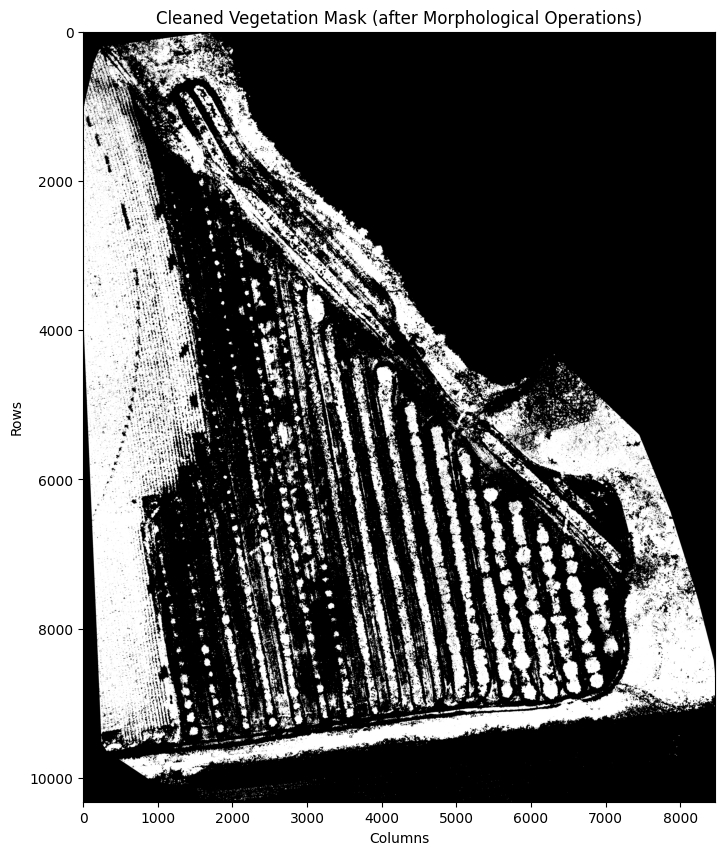

In [28]:
from scipy.ndimage import binary_erosion, binary_dilation

# Define a structuring element (kernel) for morphological operations
# A larger kernel will have a stronger effect
kernel_size = 3 # You can experiment with different sizes (e.g., 3, 5, 7)
kernel = np.ones((kernel_size, kernel_size), dtype=bool)

# Perform morphological opening (erosion followed by dilation) to remove small objects and smooth contours
opened_mask = binary_erosion(vegetation_mask, structure=kernel)
cleaned_mask = binary_dilation(opened_mask, structure=kernel)

# You might also consider a closing operation (dilation followed by erosion) to fill small holes
# closed_mask = binary_dilation(vegetation_mask, structure=kernel)
# cleaned_mask = binary_erosion(closed_mask, structure=kernel)


plt.figure(figsize=(10, 10))
plt.imshow(cleaned_mask, cmap='Greys_r')
plt.title('Cleaned Vegetation Mask (after Morphological Operations)')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

### 4. Segmentation: Delineate Individual Tree Crowns

Now, we'll use connected component labeling to identify individual tree crowns from the cleaned vegetation mask. This will assign a unique label to each separated tree.

For more advanced scenarios or overlapping trees, watershed segmentation might be considered.

Number of potential tree crowns identified: 5793


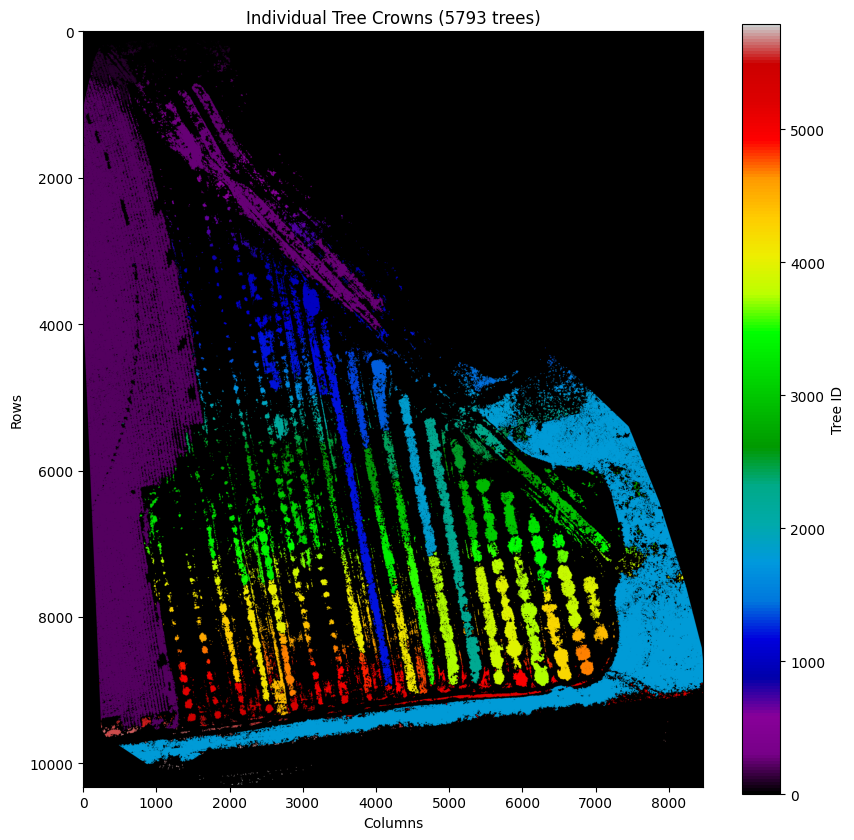

In [29]:
from skimage.measure import label, regionprops
from skimage.morphology import remove_small_objects

# Remove very small objects that might be noise remaining after morphology
# You might need to adjust the 'min_size' based on the expected size of tree crowns
min_tree_pixel_area = 50 # Example: adjust this value
cleaned_mask_final = remove_small_objects(cleaned_mask, min_size=min_tree_pixel_area)

# Label connected components (each tree will get a unique integer ID)
labeled_trees = label(cleaned_mask_final)
num_trees = labeled_trees.max()
print(f"Number of potential tree crowns identified: {num_trees}")

# Visualize the labeled trees
plt.figure(figsize=(10, 10))
plt.imshow(labeled_trees, cmap='nipy_spectral') # Use a colormap to distinguish labels
plt.title(f'Individual Tree Crowns ({num_trees} trees)')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.colorbar(label='Tree ID')
plt.show()

# You can also iterate through regions and get properties of each tree
# For example, to get the area of each tree:
# print("\n--- Tree Properties ---")
# for region in regionprops(labeled_trees):
#     if region.area > 0:
#         print(f"Tree ID: {region.label}, Area: {region.area} pixels")

In [33]:
!pip install fiona shapely -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 73.4 MB/s eta 0:00:00


In [37]:
import fiona
import shapely.geometry
from skimage.measure import regionprops, find_contours

# Re-open the stacked image to get the transform and CRS
with rasterio.open(output_path) as src:
    transform = src.transform
    crs = src.crs

# Prepare to store GeoJSON features
features = []

print("Processing tree crowns...")
for region in regionprops(labeled_trees):
    if region.area >= min_tree_pixel_area: # Only include trees that passed the min_tree_pixel_area filter
        # Get the binary mask for the current region
        tree_mask = region.image

        # Find contours for this tree mask. 'level=0.5' is standard for binary images
        # The coordinates are relative to the bounding box of the region
        contours = find_contours(tree_mask, level=0.5)

        if contours:
            # Assuming the largest contour is the exterior, others are holes
            # find_contours returns (row, col) coordinates
            # Convert to (x, y) pixel coordinates relative to the region's bbox
            exterior_contour = contours[0]

            # Transform local bbox coordinates to global image coordinates
            min_row, min_col, _, _ = region.bbox

            # Convert contours from (row, col) in local bbox to (x, y) in global image
            global_coords = []
            for r, c in exterior_contour:
                # Adjust row/col to global image coordinates
                global_r = r + min_row
                global_c = c + min_col
                # Convert to geographic coordinates using the affine transform
                x, y = transform * (global_c, global_r) # affine transform expects (col, row)
                global_coords.append((x, y))

            if global_coords:
                # Ensure the contour has enough points to form a valid polygon
                # A linear ring requires at least 4 coordinates (3 distinct + closing point)
                if len(global_coords) < 4:
                    # Skip this contour if it's too short to form a polygon
                    continue

                # Ensure the polygon is closed (first and last point are the same)
                if global_coords[0] != global_coords[-1]:
                    global_coords.append(global_coords[0])

                # Create a Shapely Polygon from the transformed coordinates
                polygon = shapely.geometry.Polygon(global_coords)

                # Add properties for the feature
                properties = {
                    'tree_id': region.label,
                    'area_pixels': region.area
                }

                # Append as a GeoJSON-like feature dictionary
                features.append({
                    'geometry': shapely.geometry.mapping(polygon),
                    'properties': properties
                })

print(f"Exporting {len(features)} tree polygons.")

# Define the schema for the GeoJSON file
schema = {
    'geometry': 'Polygon',
    'properties': {
        'tree_id': 'int',
        'area_pixels': 'int'
    }
}

# Define the output GeoJSON file path
output_geojson_path = '/content/delineated_citrus_trees.geojson'

# Write the features to a GeoJSON file
with fiona.open(
    output_geojson_path,
    'w',
    driver='GeoJSON',
    crs=crs,
    schema=schema
) as collection:
    for feature in features:
        collection.write(feature)

print(f"Delineated tree crowns exported to {output_geojson_path}")

Processing tree crowns...
Exporting 5214 tree polygons.
Delineated tree crowns exported to /content/delineated_citrus_trees.geojson


In [31]:
from google.colab import files
files.download('/content/delineated_citrus_trees.geojson')

FileNotFoundError: Cannot find file: /content/delineated_citrus_trees.geojson

### Perform Gray-Level Co-occurrence Matrix (GLCM) Analysis

GLCM is a powerful tool for extracting texture features from images. We will calculate several common texture properties for each of the stacked spectral bands. Since the original images are 16-bit, we will first quantize them to 256 gray levels to make GLCM computation feasible.

In [1]:
!pip install --upgrade scikit-image -q

from skimage.feature import greycomatrix, greycoprops
from skimage import exposure
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import rasterio

# Re-open the stacked image to get the data and band descriptions
output_path = "/content/stacked_4band.tif"
with rasterio.open(output_path) as src:
    stacked_data = src.read()
    band_descriptions = src.descriptions

# --- GLCM Parameters ---
# Distances: The pixel pair distances over which to calculate GLCM
distances = [1] # Considering adjacent pixels
# Angles: The directions in which to consider pixel pairs (0, 45, 90, 135 degrees)
angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]
# Number of gray levels to quantize the image to
# 256 is common, but can be reduced further (e.g., 32 or 64) for performance
levels = 256

def quantize_band(band_data, levels):
    """Rescales a band's pixel values to a specified number of gray levels."""
    # Use exposure.rescale_intensity to map values to the new range [0, levels-1]
    min_val = np.min(band_data)
    max_val = np.max(band_data)
    if max_val == min_val:
        return np.zeros_like(band_data, dtype=int) # Handle flat images

    # Rescale to [0, levels-1] and convert to integer type
    quantized_band = exposure.rescale_intensity(
        band_data,
        in_range=(min_val, max_val),
        out_range=(0, levels - 1)
    ).astype(int)
    return quantized_band

# Store GLCM properties
gLCM_features = pd.DataFrame(columns=['Band', 'Property', 'Mean_Value'])

print("Calculating GLCM features for each band...")

for i, band_name in enumerate(band_descriptions):
    print(f"Processing band: {band_name}")
    band = stacked_data[i, :, :]

    # Quantize the band to the specified number of levels
    quantized_band = quantize_band(band, levels)

    # Calculate GLCM
    # Ensure quantized_band is 2D, as greycomatrix expects a 2D array
    glcm = greycomatrix(
        quantized_band,
        distances=distances,
        angles=angles,
        levels=levels,
        symmetric=True,
        normed=True
    )

    # Extract GLCM properties
    properties = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']
    for prop in properties:
        feature = greycoprops(glcm, prop)[0] # [0] because we use a single distance
        mean_feature = np.mean(feature) # Average across angles
        gLCM_features = pd.concat([
            gLCM_features,
            pd.DataFrame([{'Band': band_name, 'Property': prop, 'Mean_Value': mean_feature}])
        ], ignore_index=True)

display(gLCM_features)

print("GLCM feature calculation complete.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 82.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cucim-cu12 26.2.0 requires scikit-image<0.26.0,>=0.19.0, but you have scikit-image 0.26.0 which is incompatible.


ImportError: cannot import name 'greycomatrix' from 'skimage.feature' (/usr/local/lib/python3.12/dist-packages/skimage/feature/__init__.py)

#### Visualize a Sample Texture Feature (Contrast)

Let's visualize the contrast map for one of the bands to see how texture varies spatially. This involves calculating the contrast for each pixel based on its local neighborhood.

In [39]:
# Select a band for visualization (e.g., the 'red' band)
selected_band_name = 'red'
selected_band_idx = band_descriptions.index(selected_band_name)
selected_band = stacked_data[selected_band_idx, :, :]

# Quantize the selected band
quantized_selected_band = quantize_band(selected_band, levels)

# Initialize an array to store the local contrast values
contrast_map = np.zeros(quantized_selected_band.shape)

# Define a window size for local GLCM calculation (e.g., 5x5 pixels)
window_size = 5
half_window = window_size // 2

# Iterate over the image, calculating local GLCM for each window
# This can be computationally intensive for large images. Consider sampling or parallelization if needed.
print(f"Calculating local contrast map for {selected_band_name} band (this may take some time)...")

# Loop over the image with a sliding window
for r in range(half_window, quantized_selected_band.shape[0] - half_window):
    for c in range(half_window, quantized_selected_band.shape[1] - half_window):
        window = quantized_selected_band[r - half_window : r + half_window + 1,
                                         c - half_window : c + half_window + 1]

        # Ensure the window is not constant to avoid issues with greycomatrix
        if np.max(window) == np.min(window):
            contrast_map[r, c] = 0.0 # Or some default value for flat areas
            continue

        # Compute GLCM for the local window
        local_glcm = greycomatrix(window, distances=distances, angles=angles, levels=levels, symmetric=True, normed=True)

        # Extract contrast property and average across angles
        local_contrast = np.mean(greycoprops(local_glcm, 'contrast')[0])
        contrast_map[r, c] = local_contrast

# Display the contrast map
plt.figure(figsize=(10, 10))
plt.imshow(contrast_map, cmap='viridis')
plt.colorbar(label='Contrast Value')
plt.title(f'GLCM Contrast Map for {selected_band_name} Band (Window Size: {window_size}x{window_size})')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

NameError: name 'quantize_band' is not defined

Once your Drive is mounted, you can specify the path to your data. For example, if your file is named `my_data.csv` and it's located in a folder called `My_Data` in your Drive, the path would be `/content/drive/MyDrive/My_Data/my_data.csv`.